In [2]:
import os
import pandas as pd

# Function to load IMDB dataset from folders
def load_imdb_dataset(base_path):
    data = {"review": [], "label": []}

    for label_type in ["pos", "neg"]:
        dir_name = os.path.join(base_path, label_type)
        for filename in os.listdir(dir_name):
            if filename.endswith(".txt"):
                with open(os.path.join(dir_name, filename), encoding="utf-8") as f:
                    data["review"].append(f.read())
                    data["label"].append(1 if label_type == "pos" else 0)
    
    return pd.DataFrame(data)

In [3]:
# Paths (update this path to where you unzipped aclImdb/)
train_path = "aclImdb/train"
test_path = "aclImdb/test"

# Load train and test datasets
df_train = load_imdb_dataset(train_path)
df_test = load_imdb_dataset(test_path)

# Inspect the dataset
# Make pandas show long text without truncating
pd.set_option("display.max_colwidth", None)
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
df_train.head(10)

Train shape: (25000, 2)
Test shape: (25000, 2)


,review,label
0,"Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as ""Teachers"". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is ""Teachers"". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!",1
1,"Homelessness (or Houselessness as George Carlin stated) has been an issue for years but never a plan to help those on the street that were once considered human who did everything from going to school, work, or vote for the matter. Most people think of the homeless as just a lost cause while worrying about things such as racism, the war on Iraq, pressuring kids to succeed, technology, the elections, inflation, or worrying if they'll be next to end up on the streets.<br /><br />But what if you were given a bet to live on the streets for a month without the luxuries you once had from a home, the entertainment sets, a bathroom, pictures on the wall, a computer, and everything you once treasure to see what it's like to be homeless? That is Goddard Bolt's lesson.<br /><br />Mel Brooks (who directs) who stars as Bolt plays a rich man who has everything in the world until deciding to make a bet with a sissy rival (Jeffery Tambor) to see if he can live in the streets for thirty days without the luxuries; if Bolt succeeds, he can do what he wants with a future project of making more buildings. The bet's on where Bolt is thrown on the street with a bracelet on his leg to monitor his every move where he can't step off the sidewalk. He's given the nickname Pepto by a vagrant after it's written on his forehead where Bolt meets other characters including a woman by the name of Molly (Lesley Ann Warren) an ex-dancer who got divorce before losing her home, and her pals Sailor (Howard Morris) and Fumes (Teddy Wilson) who are already used to the streets. They're survivors. Bolt isn't. He's not used to reaching mutual agreements like he once did when being rich where it's fight or flight, kill or be killed.<br /><br />While the love connection between Molly and Bolt wasn't necessary to plot, I found ""Life Stinks"" to be one of Mel Brooks' observant films where prior to being a comedy, it shows a tender side compared to his slapstick work such as Blazing Saddles, Young Frankenstein, or Spaceballs for the matter, to show what it's like having something valuable before losing it the next day or on the other hand making a stupid bet like all rich people do when they don't know what to do with their money. Maybe they should give it to the homeless instead of using it like Monopoly money.<br /><br />Or maybe this film will inspire you to help others.",1
2,"Brilliant over-acting by Lesley Ann Warren. Best dramatic hobo lady I have ever seen, and love scenes in clothes warehouse are second to none. The corn on face is a classic, as good as anything in Blazing Saddles. The take on lawyers is also superb. After being accused of being a turncoat, selling out his boss, and being dishonest the lawyer of Pepto Bolt shrugs indifferently ""I'm a lawyer"" he says. Three funny words. Jeffrey Tambor, a favorite from the later Larry Sanders show, is fantastic here too as a mad millionaire who wants to crush the ghetto. His character is more malevolent than usual. The hospital scene, and the scene where the homeless invade a demolition site, are all-time classics. Look for the legs scene and the two big diggers fighting (one bleeds). This movie ge

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Accuracy: 0.8509201275178437

Test Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0      0.882     0.878     0.880     12500
           1      0.878     0.882     0.880     12500

    accuracy                          0.880     25000
   macro avg      0.880     0.880     0.880     25000
weighted avg      0.880     0.880     0.880     25000



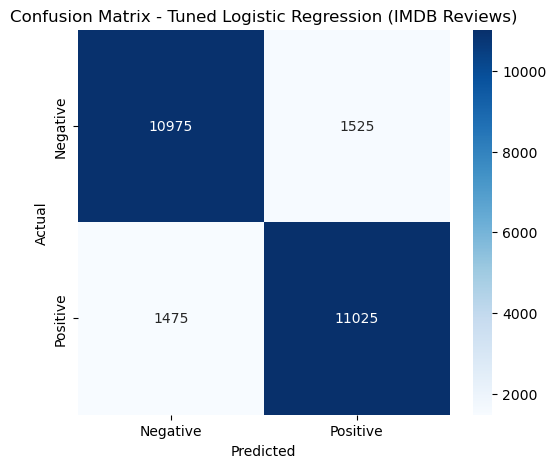

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Vectorize text (convert reviews -> TF-IDF features)
vectorizer = TfidfVectorizer(max_features=10000, stop_words="english")
X_train = vectorizer.fit_transform(df_train["review"])
X_test = vectorizer.transform(df_test["review"])

y_train = df_train["label"]
y_test = df_test["label"]

# 2. Define Logistic Regression + GridSearch
param_grid = {
    "solver": ["lbfgs"],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],   # regularization strength
    "penalty": ["l2"],         # "l1" only works with liblinear & saga
}
log_reg = LogisticRegression(max_iter=2000)

grid = GridSearchCV(log_reg, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# 3. Evaluate on test data
best_lr = grid.best_estimator_
y_pred = best_lr.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Logistic Regression (IMDB Reviews)")
plt.show()

Logistic Regression: 0.8796
Naive Bayes: 0.8344
Random Forest: 0.8435


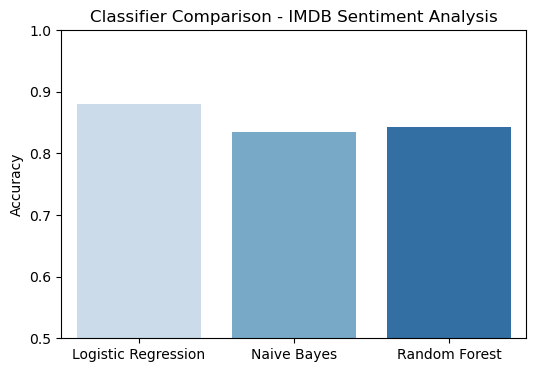

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# --- Train Naive Bayes ---
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

# --- Train Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# --- Logistic Regression (already trained in Cell 3) ---
acc_lr = accuracy_score(y_test, y_pred)

# --- Compare Results ---
results = {
    "Logistic Regression": acc_lr,
    "Naive Bayes": acc_nb,
    "Random Forest": acc_rf
}

# Print results
for clf, acc in results.items():
    print(f"{clf}: {acc:.4f}")

# --- Bar chart ---
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), hue=list(results.keys()), 
            palette="Blues", legend=False)
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)  # make comparison clearer
plt.title("Classifier Comparison - IMDB Sentiment Analysis")
plt.show()


In [11]:
from sklearn.metrics import classification_report

# Logistic Regression report
print("Logistic Regression:\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Naive Bayes report
print("\nNaive Bayes:\n")
print(classification_report(y_test, y_pred_nb, target_names=["Negative", "Positive"]))

# Random Forest report
print("\nRandom Forest:\n")
print(classification_report(y_test, y_pred_rf, target_names=["Negative", "Positive"]))


Logistic Regression:

              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


Naive Bayes:

              precision    recall  f1-score   support

    Negative       0.81      0.87      0.84     12500
    Positive       0.86      0.80      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000


Random Forest:

              precision    recall  f1-score   support

    Negative       0.83      0.87      0.85     12500
    Positive       0.86      0.82      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0


Performance Comparison:
            Classifier  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.880      0.878   0.882     0.880
1          Naive Bayes     0.834      0.861   0.798     0.828
2        Random Forest     0.844      0.859   0.821     0.840


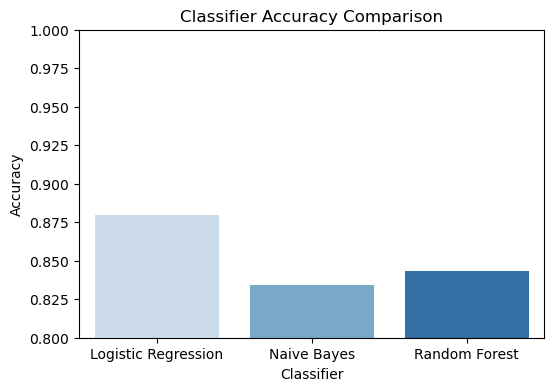

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Train and evaluate multiple classifiers
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
metrics_table = []

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = acc
    metrics_table.append([name, acc, prec, rec, f1])

# Create metrics DataFrame
df_metrics = pd.DataFrame(metrics_table, columns=["Classifier", "Accuracy", "Precision", "Recall", "F1-Score"])

# Print metrics table
print("\nPerformance Comparison:")
print(df_metrics.round(3))

# Plot bar chart of accuracies
plt.figure(figsize=(6,4))
sns.barplot(x="Classifier", y="Accuracy", hue="Classifier", data=df_metrics, legend=False, palette="Blues")
plt.ylim(0.8, 1.0)
plt.title("Classifier Accuracy Comparison")
plt.show()
